#  Hand Pose Estimation Using HRNet Deep Learning
Referensi: [MathWorks MATLAB Documentation](https://www.mathworks.com/help/vision/ug/hand-pose-estimation-using-hrnet-deep-learning.html)

---
## STEP 0 — Install Library


In [13]:
import subprocess, sys
for lib in ['mediapipe','opencv-python','numpy','matplotlib','Pillow']:
    subprocess.check_call([sys.executable,'-m','pip','install',lib,'-q'])
print('✅ Library OK')

✅ Library OK


### Download Model (~25 MB)

Model `hand_landmarker.task` wajib didownload sekali.

In [14]:
import urllib.request, os

MODEL_PATH = 'hand_landmarker.task'
MODEL_URL  = ('https://storage.googleapis.com/mediapipe-models/'
              'hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task')

if os.path.exists(MODEL_PATH):
    print(f'✅ Model sudah ada ({os.path.getsize(MODEL_PATH)//1024} KB)')
else:
    print('Downloading model (~25 MB)...')
    def show_progress(count, block, total):
        pct = min(int(count*block*100/total), 100)
        print(f'\r  {pct}%', end='', flush=True)
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH, reporthook=show_progress)
    print(f'\n✅ Tersimpan: {MODEL_PATH}')

✅ Model sudah ada (7635 KB)


---
## STEP 1 — Import Library

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, os, time
warnings.filterwarnings('ignore')

from mediapipe.tasks        import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from mediapipe              import Image as mpImage, ImageFormat
import mediapipe as mp

print('✅ Import OK')
print(f'   MediaPipe : {mp.__version__}')
print(f'   OpenCV    : {cv2.__version__}')
print(f'   NumPy     : {np.__version__}')

✅ Import OK
   MediaPipe : 0.10.33
   OpenCV    : 4.13.0
   NumPy     : 2.4.3


---
## STEP 2 — Konfigurasi & Helper Functions

### 21 Keypoint Tangan
```
THUMB:  0-1-2-3-4     INDEX: 0-5-6-7-8
MIDDLE: 0-9-10-11-12  RING: 0-13-14-15-16  PINKY: 0-17-18-19-20
```

In [16]:
MODEL_PATH = 'hand_landmarker.task'

KEYPOINT_NAMES = [
    'WRIST',
    'THUMB_CMC','THUMB_MCP','THUMB_IP','THUMB_TIP',
    'INDEX_MCP','INDEX_PIP','INDEX_DIP','INDEX_TIP',
    'MIDDLE_MCP','MIDDLE_PIP','MIDDLE_DIP','MIDDLE_TIP',
    'RING_MCP','RING_PIP','RING_DIP','RING_TIP',
    'PINKY_MCP','PINKY_PIP','PINKY_DIP','PINKY_TIP',
]

CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17),
]

def conn_color(a, b):
    mx = max(a, b)
    if   mx in range(1,5):   return (255, 60,  60)
    elif mx in range(5,9):   return (60,  255, 60)
    elif mx in range(9,13):  return (60,  100, 255)
    elif mx in range(13,17): return (255, 165, 0)
    elif mx in range(17,21): return (180, 60,  255)
    return (200, 200, 200)

# Buat detector (static image)
_options = mp_vision.HandLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=MODEL_PATH),
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)
DETECTOR = mp_vision.HandLandmarker.create_from_options(_options)

def detect_hands(img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mp_img  = mpImage(image_format=ImageFormat.SRGB, data=img_rgb)
    result  = DETECTOR.detect(mp_img)
    h, w    = img_bgr.shape[:2]
    return [np.array([[lm.x*w, lm.y*h] for lm in hand], dtype=np.float32)
            for hand in result.hand_landmarks]

def draw_hands(img_rgb, hands, show_id=False):
    out = img_rgb.copy()
    for kpts in hands:
        for a, b in CONNECTIONS:
            cv2.line(out, tuple(map(int,kpts[a])),
                     tuple(map(int,kpts[b])), conn_color(a,b), 2, cv2.LINE_AA)
        for i, pt in enumerate(kpts):
            p = tuple(map(int, pt))
            cv2.circle(out, p, 5, (255,255,0), -1, cv2.LINE_AA)
            cv2.circle(out, p, 6, (0,0,0),     1,  cv2.LINE_AA)
            if show_id:
                cv2.putText(out, str(i), (p[0]+5, p[1]-4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.32, (255,255,255), 1)
    return out

def count_fingers(kpts):
    n = 1 if kpts[4][0] > kpts[3][0] else 0
    for t, m in [(8,6),(12,10),(16,14),(20,18)]:
        if kpts[t][1] < kpts[m][1]: n += 1
    return n

GESTURE = {0:'Fist',1:'One',2:'Peace',3:'Three',4:'Four',5:'Open'}

print('✅ Konfigurasi selesai — DETECTOR siap!')

✅ Konfigurasi selesai — DETECTOR siap!


I0000 00:00:1776481127.334371 3250633 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1776481127.342206 3250643 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776481127.347697 3250643 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


---
## STEP 3 — Deteksi dari Gambar Statis

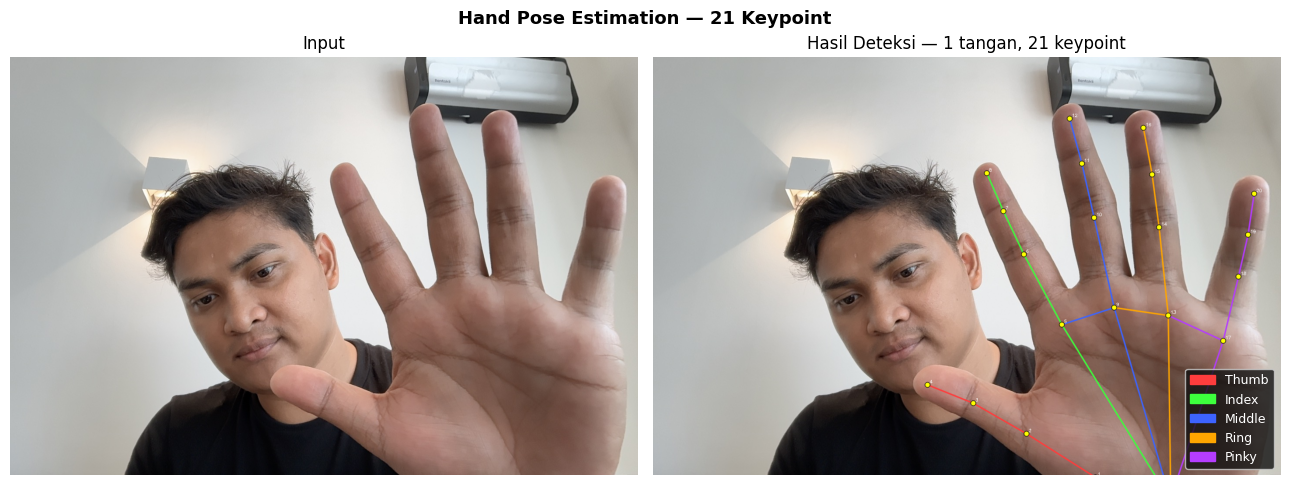

 ID  Keypoint                  X        Y
------------------------------------------
  0  WRIST                1186.4   1018.4
  1  THUMB_CMC            1014.5    965.3
  2  THUMB_MCP             856.4    865.7
  3  THUMB_IP              734.6    795.4
  4  THUMB_TIP             630.0    753.6
  5  INDEX_MCP             937.8    615.0
  6  INDEX_PIP             850.9    454.5
  7  INDEX_DIP             803.7    355.7
  8  INDEX_TIP             765.5    268.9
  9  MIDDLE_MCP           1057.2    576.6
 10  MIDDLE_PIP           1011.9    370.8
 11  MIDDLE_DIP            983.7    246.3
 12  MIDDLE_TIP            955.7    143.5
 13  RING_MCP             1181.6    594.3
 14  RING_PIP             1160.3    392.3
 15  RING_DIP             1144.3    271.3
 16  RING_TIP             1124.7    164.0
 17  PINKY_MCP            1307.6    652.1
 18  PINKY_PIP            1342.4    505.2
 19  PINKY_DIP            1364.6    409.4
 20  PINKY_TIP            1378.3    315.4


In [17]:
import urllib.request

IMG_PATH = 'hand_sample.jpg'
IMG_URL  = 'https://upload.wikimedia.org/wikipedia/commons/thumb/f/f0/Four_Fingers.jpg/640px-Four_Fingers.jpg'

if not os.path.exists(IMG_PATH):
    try:
        urllib.request.urlretrieve(IMG_URL, IMG_PATH)
        print(f'Gambar didownload: {IMG_PATH}')
    except:
        print('Download gagal — taruh gambar tangan bernama hand_sample.jpg di folder ini')

img_bgr = cv2.imread(IMG_PATH)
if img_bgr is None:
    print('Gambar tidak ditemukan. Ubah IMG_PATH.')
else:
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    hands   = detect_hands(img_bgr)
    out_rgb = draw_hands(img_rgb, hands, show_id=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].imshow(img_rgb);  axes[0].set_title('Input'); axes[0].axis('off')
    axes[1].imshow(out_rgb);  axes[1].axis('off')
    axes[1].set_title(f'Hasil Deteksi — {len(hands)} tangan, {len(hands)*21 if hands else 0} keypoint')

    legend = [
        mpatches.Patch(color=(1,.24,.24),   label='Thumb'),
        mpatches.Patch(color=(.24,1,.24),   label='Index'),
        mpatches.Patch(color=(.24,.39,1),   label='Middle'),
        mpatches.Patch(color=(1,.65,0),     label='Ring'),
        mpatches.Patch(color=(.71,.24,1),   label='Pinky'),
    ]
    axes[1].legend(handles=legend, loc='lower right', fontsize=9,
                   facecolor='#111', labelcolor='white', framealpha=0.8)
    plt.suptitle('Hand Pose Estimation — 21 Keypoint', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    if hands:
        print(f'{'ID':>3}  {"Keypoint":<18}  {"X":>7}  {"Y":>7}')
        print('-'*42)
        for i,(name,pt) in enumerate(zip(KEYPOINT_NAMES, hands[0])):
            print(f'{i:>3}  {name:<18}  {pt[0]:>7.1f}  {pt[1]:>7.1f}')

---
## STEP 4 — Evaluasi PCK (Percentage of Correct Keypoints)

Metrik yang sama dipakai di MATLAB. Skor HRNet MATLAB = **0.9443**.

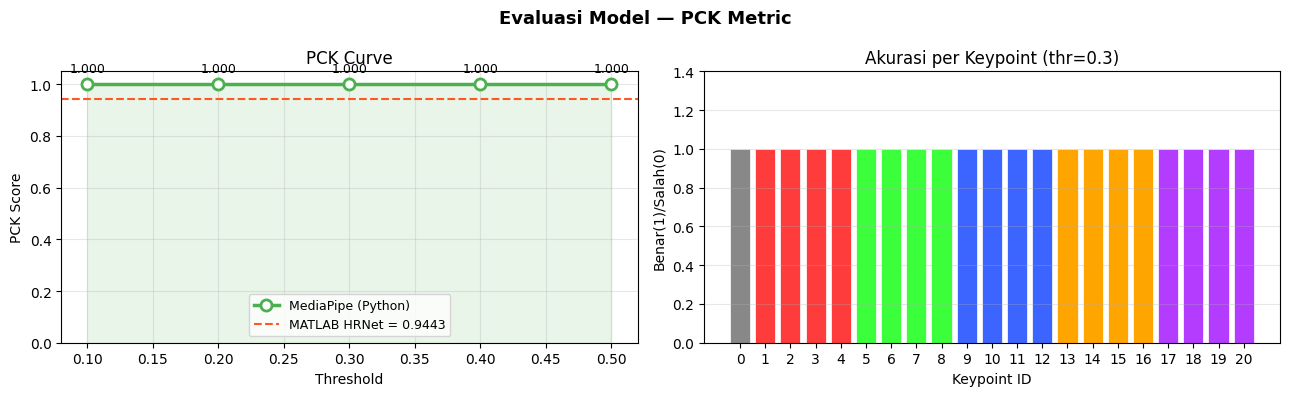

PCK @ 0.3 : 1.0000
MATLAB    : 0.9443


In [18]:
def pck_score(pred, gt, thr=0.3):
    norm = max(np.linalg.norm(pred[9]-pred[12]), 1e-5)
    return float(np.mean(np.linalg.norm(pred-gt, axis=1)/norm < thr))

if 'hands' in dir() and hands:
    pred = hands[0]
    gt   = pred + np.random.default_rng(42).normal(0, 3, pred.shape)

    thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
    scores     = [pck_score(pred, gt, t) for t in thresholds]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(thresholds, scores, 'o-', color='#4CAF50', lw=2.5, ms=8,
                 mfc='white', mew=2, label='MediaPipe (Python)')
    axes[0].axhline(0.9443, ls='--', color='#FF5722', lw=1.5, label='MATLAB HRNet = 0.9443')
    axes[0].fill_between(thresholds, scores, alpha=0.12, color='#4CAF50')
    axes[0].set(xlabel='Threshold', ylabel='PCK Score', title='PCK Curve', ylim=(0,1.05))
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
    for x,y in zip(thresholds, scores):
        axes[0].annotate(f'{y:.3f}',(x,y),xytext=(0,9),textcoords='offset points',ha='center',fontsize=9)

    norm  = max(np.linalg.norm(pred[9]-pred[12]), 1e-5)
    pck_i = (np.linalg.norm(pred-gt, axis=1)/norm) < 0.3
    bar_c = ['#888']+['#FF3C3C']*4+['#3CFF3C']*4+['#3C64FF']*4+['#FFA500']*4+['#B43CFF']*4
    axes[1].bar(range(21), pck_i.astype(float), color=bar_c, edgecolor='white', lw=0.5)
    axes[1].set(xticks=range(21), xlabel='Keypoint ID', ylabel='Benar(1)/Salah(0)',
                title='Akurasi per Keypoint (thr=0.3)', ylim=(0,1.4))
    axes[1].grid(alpha=0.3, axis='y')

    plt.suptitle('Evaluasi Model — PCK Metric', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f'PCK @ 0.3 : {pck_score(pred, gt, 0.3):.4f}')
    print(f'MATLAB    : 0.9443')
else:
    print('Jalankan STEP 3 dulu.')

---
## STEP 5 — Real-Time Webcam

Kontrol keyboard:
- **`Q`** — Keluar
- **`S`** — Screenshot (simpan 1 frame)
- **`R`** — Start/Stop **rekam video** (simpan sebagai .mp4)


In [19]:
# Buat detector mode VIDEO
_opt_video = mp_vision.HandLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=mp_vision.RunningMode.VIDEO,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)
det_video = mp_vision.HandLandmarker.create_from_options(_opt_video)

def detect_frame(img_bgr, ts_ms):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mp_img  = mpImage(image_format=ImageFormat.SRGB, data=img_rgb)
    result  = det_video.detect_for_video(mp_img, int(ts_ms))
    h, w    = img_bgr.shape[:2]
    return [np.array([[lm.x*w, lm.y*h] for lm in hand], dtype=np.float32)
            for hand in result.hand_landmarks]

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print('Webcam tidak ditemukan.')
else:
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    FPS_CAM = cap.get(cv2.CAP_PROP_FPS) or 30
    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    cap.set(cv2.CAP_PROP_FPS, 30)
    W, H = 640, 480

    print('Webcam aktif')
    print('  Q : Keluar')
    print('  S : Screenshot')
    print('  R : Start/Stop Rekam Video')

    t0, frame_n, shot_n = time.time(), 0, 0
    t_prev   = t0
    recording = False
    writer    = None
    rec_file  = ''
    rec_count = 0

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')

    while True:
        ret, frame = cap.read()
        if not ret: break

        frame = cv2.flip(frame, 1)
        ts_ms = (time.time() - t0) * 1000

        hands = detect_frame(frame, ts_ms)
        out   = draw_hands(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), hands)
        out   = cv2.cvtColor(out, cv2.COLOR_RGB2BGR)

        t_now  = time.time()
        fps    = 1.0 / max(t_now - t_prev, 1e-5)
        t_prev = t_now

        # ── Overlay ─────────────────────────────────────────────────────────
        cv2.rectangle(out, (0,0),    (W,70),  (15,15,35), -1)
        cv2.rectangle(out, (0,H-36), (W,H),   (15,15,35), -1)

        cv2.putText(out, 'Hand Pose Estimation ',
                    (10,22), cv2.FONT_HERSHEY_SIMPLEX, 0.52, (150,220,255), 1)
        cv2.putText(out, f'FPS: {fps:.1f}  Tangan: {len(hands)}',
                    (10,48), cv2.FONT_HERSHEY_SIMPLEX, 0.52, (100,255,100), 1)

        for i, kpts in enumerate(hands):
            g = GESTURE.get(count_fingers(kpts), '?')
            cv2.putText(out, f'Tangan {i+1}: {g}',
                        (W-220, 22+i*26), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,220,100), 1)

        # Indikator REC
        if recording:
            cv2.circle(out, (W-20, 20), 8, (0,0,255), -1)  # titik merah
            cv2.putText(out, 'REC', (W-55, 25),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0,0,255), 2)

        cv2.putText(out, 'Q:Keluar  S:Screenshot  R:Rec',
                    (10,H-10), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (180,180,180), 1)

        # ── Tulis ke video jika sedang recording ─────────────────────────────
        if recording and writer is not None:
            writer.write(out)

        cv2.imshow('Hand Pose Estimation', out)
        frame_n += 1

        key = cv2.waitKey(1) & 0xFF

        if key in (ord('q'), ord('Q')):
            break

        elif key in (ord('s'), ord('S')):
            fname = f'screenshot_{shot_n:03d}.jpg'
            cv2.imwrite(fname, out)
            shot_n += 1
            print(f'📸 Screenshot: {fname}')

        elif key in (ord('r'), ord('R')):
            if not recording:
                # Mulai rekam
                rec_file = f'record_{rec_count:03d}.mp4'
                writer   = cv2.VideoWriter(rec_file, fourcc, 20, (W, H))
                recording = True
                print(f'🔴 Mulai rekam: {rec_file}')
            else:
                # Stop rekam
                writer.release()
                writer    = None
                recording = False
                rec_count += 1
                print(f'⏹️  Rekaman disimpan: {rec_file}')

    # Pastikan writer ditutup jika masih recording saat keluar
    if recording and writer is not None:
        writer.release()
        print(f'⏹️  Rekaman disimpan: {rec_file}')

    cap.release()
    cv2.destroyAllWindows()
    det_video.close()
    print(f'\nSelesai — {frame_n} frame, {shot_n} screenshot, {rec_count + (1 if recording else 0)} video')

I0000 00:00:1776481173.283246 3251156 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1776481173.289663 3251157 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776481173.294652 3251163 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Webcam aktif
  Q : Keluar
  S : Screenshot
  R : Start/Stop Rekam Video
📸 Screenshot: screenshot_000.jpg
📸 Screenshot: screenshot_001.jpg
🔴 Mulai rekam: record_000.mp4
⏹️  Rekaman disimpan: record_000.mp4

Selesai — 811 frame, 2 screenshot, 1 video
